In [ ]:
import torch
print(torch.__version__)


2.5.1+cu121


# EX1

In [ ]:
import torch

A = torch.tensor([[4, 5], [-2, 1], [0, 6]], dtype=torch.float32)
B = torch.tensor([[3, 0, -1], [2, 2, 10]], dtype=torch.float32)

print("Shape of A:", A.shape)
print("Shape of B:", B.shape)

B_0 = B[0]
AB = A@B
C = B_0 + AB
print("C:", C)

x = A[:, 1]
x = x.clone().detach().requires_grad_(True)
f = -C[0] *(x * x)
print("f:", f)


if f.ndim > 0:
    f = f.sum()


f.backward()
gradient = x.grad
print("Gradient of f with respect to x:", gradient)


Shape of A: torch.Size([3, 2])
Shape of B: torch.Size([2, 3])
C: tensor([[25., 10., 45.],
        [-1.,  2., 11.],
        [15., 12., 59.]])
f: tensor([ -625.,   -10., -1620.], grad_fn=<MulBackward0>)
Gradient of f with respect to x: tensor([-250.,  -20., -540.])


# Ex2

Files already downloaded and verified
Files already downloaded and verified
Epoch 1/10, Train Loss: 4.3285, Train Accuracy: 6.56%, Val Loss: 4.0814, Val Accuracy: 9.45%
Epoch 2/10, Train Loss: 3.8022, Train Accuracy: 13.68%, Val Loss: 3.9966, Val Accuracy: 10.37%
Epoch 3/10, Train Loss: 3.5703, Train Accuracy: 17.59%, Val Loss: 3.9238, Val Accuracy: 11.73%
Epoch 4/10, Train Loss: 3.3502, Train Accuracy: 21.35%, Val Loss: 3.8491, Val Accuracy: 13.28%
Epoch 5/10, Train Loss: 3.1639, Train Accuracy: 25.50%, Val Loss: 3.8424, Val Accuracy: 13.45%
Epoch 6/10, Train Loss: 3.0226, Train Accuracy: 27.38%, Val Loss: 3.8236, Val Accuracy: 13.64%
Epoch 7/10, Train Loss: 2.8971, Train Accuracy: 30.59%, Val Loss: 3.8100, Val Accuracy: 14.66%
Epoch 8/10, Train Loss: 2.7655, Train Accuracy: 33.80%, Val Loss: 3.7835, Val Accuracy: 14.06%
Epoch 9/10, Train Loss: 2.6520, Train Accuracy: 36.85%, Val Loss: 3.7542, Val Accuracy: 15.13%
Epoch 10/10, Train Loss: 2.5181, Train Accuracy: 39.12%, Val Loss: 3.80

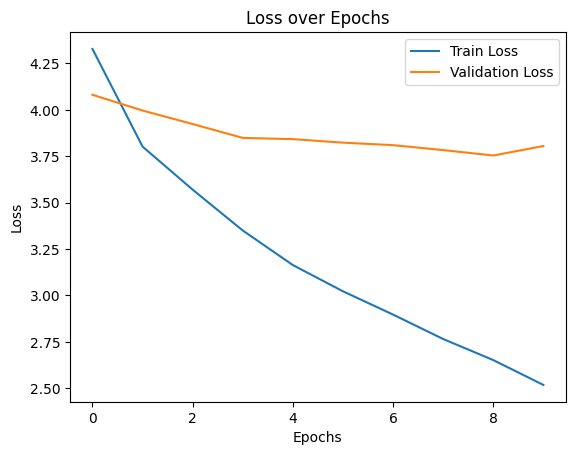

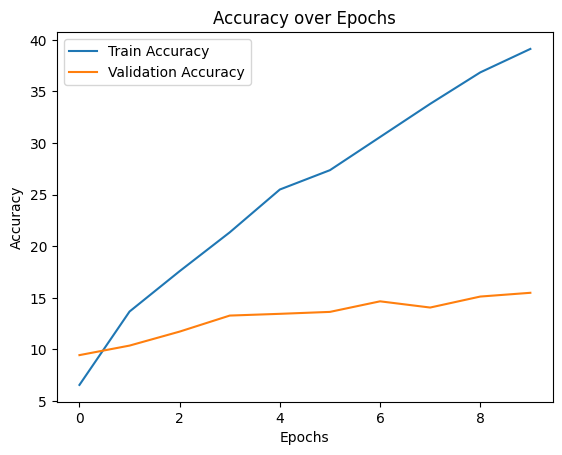

Test Loss: 3.7961, Test Accuracy: 15.66%


In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)

# Load CIFAR100 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize images
])

cifar100_train = torchvision.datasets.CIFAR100(root="./data", train=True, transform=transform, download=True)
cifar100_test = torchvision.datasets.CIFAR100(root="./data", train=False, transform=transform, download=True)

# Split the training dataset
train_size = 8000
val_size = len(cifar100_train) - train_size
train_data, val_data = torch.utils.data.random_split(cifar100_train, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# Data loaders
batch_size = 512
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(cifar100_test, batch_size=batch_size, shuffle=False, num_workers=2)

# Define the model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 1024),  # Input size for CIFAR100 images (32x32x3)
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 100)  # 100 classes for CIFAR100
        )

    def forward(self, x):
        return self.net(x)

model = MLP()

# Initialize weights
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

model.apply(init_weights)

# Define loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.3)

# Training function
def train(model, train_loader, val_loader, loss_fn, optimizer, epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    for epoch in range(epochs):
        # Training loop
        model.train()
        train_loss, train_correct = 0, 0
        for X, y in train_loader:
            optimizer.zero_grad()
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (y_pred.argmax(1) == y).sum().item()
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_correct / len(train_loader.dataset) * 100)

        # Validation loop
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                y_pred = model(X)
                val_loss += loss_fn(y_pred, y).item()
                val_correct += (y_pred.argmax(1) == y).sum().item()
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_correct / len(val_loader.dataset) * 100)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Train Accuracy: {train_accuracies[-1]:.2f}%, "
              f"Val Loss: {val_losses[-1]:.4f}, Val Accuracy: {val_accuracies[-1]:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

# Train the model
epochs = 10
train_losses, train_accuracies, val_losses, val_accuracies = train(model, train_loader, val_loader, loss_fn, optimizer, epochs)

# Plot training and validation accuracy/loss
def plot_metrics(train_metric, val_metric, metric_name):
    plt.plot(train_metric, label=f'Train {metric_name}')
    plt.plot(val_metric, label=f'Validation {metric_name}')
    plt.xlabel('Epochs')
    plt.ylabel(metric_name)
    plt.legend()
    plt.title(f'{metric_name} over Epochs')
    plt.show()

plot_metrics(train_losses, val_losses, "Loss")
plot_metrics(train_accuracies, val_accuracies, "Accuracy")

# Test the model
model.eval()
test_loss, test_correct = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        y_pred = model(X)
        test_loss += loss_fn(y_pred, y).item()
        test_correct += (y_pred.argmax(1) == y).sum().item()

test_loss /= len(test_loader)
test_accuracy = test_correct / len(cifar100_test) * 100
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


# 3

In [ ]:
import torch
import torch.nn as nn

class CustomModel(nn.Module):
    def __init__(self):
        super(CustomModel, self).__init__()
        self.layer1 = nn.Conv2d(1, 32, kernel_size=1)  # 1x1 Conv2d (32)
        self.layer2 = nn.Conv2d(32, 32, kernel_size=(3, 1), padding=(1, 0))  # 3x1 Conv2d (32), pad=1
        self.layer3 = nn.Conv2d(32, 64, kernel_size=(1, 3), padding=(0, 1))  # 1x3 Conv2d (64), pad=1
        self.layer4 = nn.Conv2d(64, 64, kernel_size=1)  # 1x1 Conv2d (64)
        self.layer5 = nn.AvgPool2d(kernel_size=2)  # 2x2 AvgPool2d
        self.layer6 = nn.Conv2d(64, 32, kernel_size=2, stride=3)  # 2x2 Conv2d (32), stride=3
        self.fc1 = nn.Linear(32 * 3 * 3, 240)  # Fully connected (240)
        self.fc2 = nn.Linear(240, 10)  # Fully connected (10)

    def forward(self, x):
        print("Input shape:", x.shape)
        x = self.layer1(x)
        print("After layer 1 (1x1 Conv2d, 32):", x.shape)
        x = self.layer2(x)
        print("After layer 2 (3x1 Conv2d, 32):", x.shape)
        x = self.layer3(x)
        print("After layer 3 (1x3 Conv2d, 64):", x.shape)
        x = self.layer4(x)
        print("After layer 4 (1x1 Conv2d, 64):", x.shape)
        x = self.layer5(x)
        print("After layer 5 (2x2 AvgPool2d):", x.shape)
        x = self.layer6(x)
        print("After layer 6 (2x2 Conv2d, stride=3, 32):", x.shape)
        x = torch.flatten(x, start_dim=1)
        print("After flatten:", x.shape)
        x = self.fc1(x)
        print("After fc1 (240):", x.shape)
        x = self.fc2(x)
        print("After fc2 (10):", x.shape)
        return x

model = CustomModel()
input_tensor = torch.randn(1, 1, 20, 20)
output = model(input_tensor)


Input shape: torch.Size([1, 1, 20, 20])
After layer 1 (1x1 Conv2d, 32): torch.Size([1, 32, 20, 20])
After layer 2 (3x1 Conv2d, 32): torch.Size([1, 32, 20, 20])
After layer 3 (1x3 Conv2d, 64): torch.Size([1, 64, 20, 20])
After layer 4 (1x1 Conv2d, 64): torch.Size([1, 64, 20, 20])
After layer 5 (2x2 AvgPool2d): torch.Size([1, 64, 10, 10])
After layer 6 (2x2 Conv2d, stride=3, 32): torch.Size([1, 32, 3, 3])
After flatten: torch.Size([1, 288])
After fc1 (240): torch.Size([1, 240])
After fc2 (10): torch.Size([1, 10])


# 4

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
import requests

# Download and preprocess the text
url = "https://s3.amazonaws.com/text-datasets/nietzsche.txt"
text = requests.get(url).text

# Create character-to-index and index-to-character mappings
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Convert text to indices
encoded_text = np.array([char_to_idx[c] for c in text])

# Hyperparameters
seq_length = 20  # Number of steps
batch_size = 1
hidden_size = 100  # Number of LSTM hidden units
num_layers = 2  # Number of LSTM layers
learning_rate = 2.5
num_epochs = 100

# Dataset and DataLoader
class TextDataset(Dataset):
    def __init__(self, text, seq_length):
        self.text = text
        self.seq_length = seq_length

    def __len__(self):
        return len(self.text) - self.seq_length

    def __getitem__(self, idx):
        x = self.text[idx:idx + self.seq_length]
        y = self.text[idx + 1:idx + self.seq_length + 1]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

dataset = TextDataset(encoded_text, seq_length)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Define the model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self, batch_size):
        return (torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device),
                torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device))

# Instantiate the model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel(vocab_size, hidden_size, num_layers).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    hidden = model.init_hidden(1)
    total_loss = 0
    for x_batch, y_batch in data_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output, hidden = model(x_batch, hidden)
        hidden = (hidden[0].detach(), hidden[1].detach())

        loss = criterion(output.view(-1, vocab_size), y_batch.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    perplexity = np.exp(total_loss / len(data_loader))
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}, Perplexity: {perplexity:.2f}")

# Generate text
def generate_text(model, start_text, length, temperature=1.0):
    model.eval()
    input_seq = torch.tensor([char_to_idx[c] for c in start_text], dtype=torch.long).unsqueeze(0).to(device)
    hidden = model.init_hidden(1)
    generated_text = start_text

    for _ in range(length):
        output, hidden = model(input_seq, hidden)
        output = output[:, -1, :] / temperature
        probs = torch.softmax(output, dim=-1).squeeze().cpu().numpy()
        char_idx = np.random.choice(len(probs), p=probs)
        generated_text += idx_to_char[char_idx]
        input_seq = torch.tensor([[char_idx]], dtype=torch.long).to(device)

    return generated_text

# Generate text from the trained model
start_text = "truth is a woman"
generated_text = generate_text(model, start_text, 50)
print("Generated text:")
print(generated_text)


Epoch 1/100, Loss: 1064144.8016, Perplexity: 5.88


# 5

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generate the dataset
def generate_data(n=200):
    x = torch.linspace(-3, 3, n).unsqueeze(1)  # Input features
    noise = torch.normal(0, 0.25, size=x.shape)  # Gaussian noise
    y = -2 * torch.cosh(x) + x * torch.tanh(x) + noise  # Target values
    return x, y

# Dataset
n = 200
x, y = generate_data(n)

# Split into training and testing sets
train_size = int(0.8 * n)
x_train, y_train = x[:train_size], y[:train_size]
x_test, y_test = x[train_size:], y[train_size:]

# Define the Nadaraya-Watson kernel regression model with parametric attention
class NWKernelRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(1, 100),
            nn.ReLU(),
            nn.Linear(100, 1)  # Scalar attention weight for each input
        )
        self.kernel_bandwidth = nn.Parameter(torch.tensor(1.0))  # Learned parameter

    def forward(self, x_query, x_key, y_value):
        # Compute attention weights
        attention_weights = torch.exp(-((x_query - x_key.T) ** 2) / (2 * self.kernel_bandwidth ** 2))
        attention_weights /= attention_weights.sum(dim=1, keepdim=True)  # Normalize

        # Predict y by weighted sum of y_value
        y_pred = attention_weights @ y_value
        return y_pred, attention_weights

# Instantiate the model, loss function, and optimizer
model = NWKernelRegressor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 20
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred, attention_weights = model(x_train, x_train, y_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Bandwidth: {model.kernel_bandwidth.item():.4f}")

# Plot predictions
model.eval()
with torch.no_grad():
    y_pred_train, _ = model(x_train, x_train, y_train)
    y_pred_test, attention_weights_test = model(x_test, x_train, y_train)

# Plot training predictions
plt.scatter(x_train, y_train, label="Training Data", alpha=0.6)
plt.plot(x_train, y_pred_train, label="Model Prediction", color="red")
plt.title("Training Predictions")
plt.legend()
plt.show()

# Plot testing predictions
plt.scatter(x_test, y_test, label="Testing Data", alpha=0.6)
plt.plot(x_test, y_pred_test, label="Model Prediction", color="red")
plt.title("Testing Predictions")
plt.legend()
plt.show()

# Plot the attention heatmap
plt.imshow(attention_weights_test.numpy(), aspect='auto', cmap='hot', extent=[x_train.min(), x_train.max(), x_test.max(), x_test.min()])
plt.colorbar(label='Attention Weight')
plt.title("Attention Heatmap")
plt.xlabel("Training Points")
plt.ylabel("Testing Points")
plt.show()

# Print the learned parameter
print(f"Learned Bandwidth Parameter (w): {model.kernel_bandwidth.item():.4f}")
